# Inference Efficiency Analysis

## Disclaimer: This notebook was constructed with assistance from Gemini 3.1 Pro for code completion, debugging, and graph styling.

## Setup

In [1]:
import os, json, csv, warnings, statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

In [2]:
RESULTS_BASE_DIR      = 'results/selection'
VISUAL_BASE_DIR       = 'unimodal/image_corruptions'
TEXTUAL_BASE_DIR      = 'unimodal/text_corruptions'
VARIANT_A_BASE_DIR    = 'multimodal/variant_a'
VARIANT_B_BASE_DIR    = 'multimodal/variant_b'
BASELINE_CSV          = 'evaluation/baseline_iou_all.csv'
VISUAL_CSV            = 'evaluation/visual/unimodal_visual_flat.csv'
TEXTUAL_CSV           = 'evaluation/textual/unimodal_textual_flat.csv'
OUTPUT_DIR            = 'evaluation/efficiency'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SCENE_TYPE_MAP = {
    'single/solo':  'Isolated',
    'single/multi': 'Clustered',
    'multi':        'Mixed',
}
SCENE_ORDER = ['Isolated', 'Clustered', 'Mixed']
EXPECTED_PER_GROUP = 250

SCENE_COLORS = {
    'Isolated':  '#4878A8',
    'Clustered': '#E07B39',
    'Mixed':     '#59A14F',
}

IMAGE_ATTACKS = [
    'jpeg_filter', 'pixelate', 'defocus_blur',
    'motion_blur', 'gaussian_noise', 'fog_filter',
]
TEXT_ATTACKS = [
    'homophone', 'synonym', 'fragmentation',
    'character_noise', 'ata_saliency',
]

ALL_IMAGE_ATTACKS = [
    'jpeg_filter', 'pixelate', 'defocus_blur', 'motion_blur',
    'gaussian_noise', 'fog_filter', 'snow_filter', 'contrast',
    'elastic', 'cutout', 'false_color', 'grayscale',
]

IMG_NICE = {
    'jpeg_filter': 'JPEG', 'pixelate': 'Pixelation',
    'defocus_blur': 'Defocus Blur', 'motion_blur': 'Motion Blur',
    'gaussian_noise': 'Gaussian Noise', 'fog_filter': 'Fog',
    'snow_filter': 'Snow', 'contrast': 'Contrast',
    'elastic': 'Elastic', 'cutout': 'Cutout',
    'false_color': 'False Color', 'grayscale': 'Grayscale',
}
TXT_NICE = {
    'homophone': 'Homophone', 'synonym': 'Synonym',
    'fragmentation': 'Fragmentation', 'character_noise': 'Char. Noise',
    'ata_saliency': 'Lex. Saliency',
}

IMG_CATEGORY_MAP = {
    'jpeg_filter': 'Digital', 'pixelate': 'Digital',
    'defocus_blur': 'Blur', 'motion_blur': 'Blur',
    'gaussian_noise': 'Noise', 'contrast': 'Color',
    'false_color': 'Color', 'grayscale': 'Color',
    'elastic': 'Geometric', 'cutout': 'Geometric',
    'fog_filter': 'Weather', 'snow_filter': 'Weather',
}
CATEGORY_ORDER = ['Digital', 'Blur', 'Noise', 'Color', 'Geometric', 'Weather']

## Load All Data Sources

### Baseline Data

In [3]:
bl = pd.read_csv(BASELINE_CSV)
bl = bl.rename(columns={'iou': 'baseline_iou'})
bl_lookup = bl.set_index(['scene_type', 'sample_id'])['baseline_iou'].to_dict()

print(f'Baseline: {len(bl)} samples loaded')
print(bl.groupby('scene_type')[['baseline_iou', 'token_count', 'runtime']].agg(['mean', 'std']).round(3))

bl_tok_mean = bl['token_count'].mean()
bl_tok_std = bl['token_count'].std()
print(f'\nBaseline overall visible tokens: {bl_tok_mean:.1f} (+- {bl_tok_std:.1f})')

Baseline: 750 samples loaded
           baseline_iou        token_count          runtime        
                   mean    std        mean      std    mean     std
scene_type                                                         
Clustered         0.841  0.126     108.716   73.527  22.968  11.501
Isolated          0.923  0.077      40.716   10.828   4.465   1.685
Mixed             0.782  0.134     160.540  121.907  35.699   7.502

Baseline overall visible tokens: 103.3 (+- 95.9)


### Unimodal Visual Data

In [4]:
df_img = pd.read_csv(VISUAL_CSV)
df_img['modality'] = 'Image'
df_img['category'] = df_img['corruption'].map(IMG_CATEGORY_MAP)

if 'baseline_iou' not in df_img.columns:
    df_img['baseline_iou'] = df_img.apply(
        lambda r: bl_lookup.get((r.scene_type, r.sample_id), np.nan), axis=1)

print(f'Visual rows: {len(df_img):,}')
print(f'Corruptions: {df_img.corruption.nunique()}')
print(f'Samples per scene type: {df_img.groupby("scene_type")["sample_id"].nunique().to_dict()}')

Visual rows: 45,000
Corruptions: 12
Samples per scene type: {'Clustered': 250, 'Isolated': 250, 'Mixed': 250}


### Unimodal Textual Data

In [5]:
df_txt = pd.read_csv(TEXTUAL_CSV)
df_txt['modality'] = 'Text'
df_txt['category'] = df_txt['corruption'].map({
    'fragmentation': 'Orthographic', 'character_noise': 'Orthographic',
    'ata_saliency': 'Semantic', 'homophone': 'Semantic', 'synonym': 'Semantic',
    'universal_suffix': 'Instruction', 'context_rot': 'Instruction', 'reinforcement': 'Instruction',
})

if 'baseline_iou' not in df_txt.columns:
    df_txt['baseline_iou'] = df_txt.apply(
        lambda r: bl_lookup.get((r.scene_type, r.sample_id), np.nan), axis=1)

LABEL_LEVEL = ['fragmentation', 'character_noise', 'ata_saliency', 'homophone', 'synonym']
df_txt = df_txt[df_txt['corruption'].isin(LABEL_LEVEL)].copy()

print(f'Textual rows (label-level): {len(df_txt):,}')
print(f'Corruptions: {df_txt.corruption.nunique()}')

Textual rows (label-level): 18,750
Corruptions: 5


### Variant A - Multimodal Paired Attack

In [6]:
def get_scene_type(category_str):
    mapping = {
        'single/solo': 'Isolated', 'single_solo': 'Isolated',
        'single/multi': 'Clustered', 'single_multi': 'Clustered',
        'multi': 'Mixed',
    }
    cat = category_str.replace('\\', '/').strip('/')
    return mapping.get(cat, 'Unknown')

a_sample_records = []
a_solution_records = []
a_errors = []

for rel_dir, scene_label in SCENE_TYPE_MAP.items():
    group_dir = os.path.join(VARIANT_A_BASE_DIR, rel_dir)
    if not os.path.isdir(group_dir):
        a_errors.append(f'MISSING DIR: {group_dir}')
        continue
    folder_ids = sorted(
        [d for d in os.listdir(group_dir) if os.path.isdir(os.path.join(group_dir, d))],
        key=lambda x: int(x)
    )
    for fid in folder_ids:
        pf_path = os.path.join(group_dir, fid, 'pareto_front.json')
        if not os.path.isfile(pf_path):
            a_errors.append(f'MISSING: {pf_path}'); continue
        with open(pf_path) as f:
            pf = json.load(f)

        swad_idx = pf['swad_star_index']
        swad_sol = pf['solutions'][swad_idx]

        a_sample_records.append({
            'scene_type':        scene_label,
            'sample_id':         int(fid),
            'baseline_iou':      pf['baseline_iou'],
            'swad_star':         pf['swad_star'],
            'early_stopped':     pf['early_stopped'],
            'early_stop_gen':    pf.get('early_stop_generation'),
            'total_evaluations': pf['total_evaluations'],
            'skipped_evals':     pf['skipped_evaluations'],
            'n_solutions':       pf['n_solutions'],
            'n_gt_objects':      len(pf['ground_truth_bboxes']),
            'swad_iou_m':        swad_sol['objectives']['iou'],
            'swad_img_dist':     swad_sol['objectives']['img_dist'],
            'swad_txt_dist':     swad_sol['objectives']['txt_dist'],
            'swad_delta_m':      swad_sol['swad_metrics']['delta_m_plus'],
            'swad_phi':          swad_sol['swad_metrics']['phi'],
            'swad_token_count':  swad_sol['vlm_output']['token_count'],
            'swad_runtime':      swad_sol['vlm_output']['runtime_seconds'],
            'swad_img_attack':   swad_sol['genome']['img_attack'],
            'swad_img_scale':    swad_sol['genome']['img_scale'],
            'swad_txt_attack':   swad_sol['genome']['txt_attack'],
            'swad_txt_scale':    swad_sol['genome']['txt_scale'],
        })

        for sol in pf['solutions']:
            a_solution_records.append({
                'scene_type':     scene_label,
                'sample_id':      int(fid),
                'baseline_iou':   pf['baseline_iou'],
                'iou':            sol['objectives']['iou'],
                'img_dist':       sol['objectives']['img_dist'],
                'txt_dist':       sol['objectives']['txt_dist'],
                'token_count':    sol['vlm_output']['token_count'],
                'runtime_seconds':sol['vlm_output']['runtime_seconds'],
                'img_attack':     sol['genome']['img_attack'],
                'img_scale':      sol['genome']['img_scale'],
                'txt_attack':     sol['genome']['txt_attack'],
                'txt_scale':      sol['genome']['txt_scale'],
            })

df_a = pd.DataFrame(a_sample_records)
df_a_sols = pd.DataFrame(a_solution_records)
print(f'Variant A: {len(df_a)} samples, {len(df_a_sols):,} Pareto solutions')
if a_errors:
    print(f'{len(a_errors)} errors')

Variant A: 750 samples, 13,354 Pareto solutions


### Variant B - Multimodal Simultaneous Bounded Attack

In [7]:
b_sample_records = []
b_solution_records = []
b_errors = []

BUDGET_MAX = 1.0

for rel_dir, scene_label in SCENE_TYPE_MAP.items():
    group_dir = os.path.join(VARIANT_B_BASE_DIR, rel_dir)
    if not os.path.isdir(group_dir):
        b_errors.append(f'MISSING DIR: {group_dir}')
        continue
    folder_ids = sorted(
        [d for d in os.listdir(group_dir) if os.path.isdir(os.path.join(group_dir, d))],
        key=lambda x: int(x)
    )
    for fid in folder_ids:
        pf_path = os.path.join(group_dir, fid, 'pareto_front.json')
        if not os.path.isfile(pf_path):
            b_errors.append(f'MISSING: {pf_path}'); continue
        with open(pf_path) as f:
            pf = json.load(f)

        swad_idx = pf['swad_star_index']
        swad_sol = pf['solutions'][swad_idx]
        genome = swad_sol['genome']

        # Per-corruption severity scales
        img_budget = sum(genome['image_corruptions'].values())
        txt_budget = sum(genome['text_corruptions'].values())

        b_sample_records.append({
            'scene_type':        scene_label,
            'sample_id':         int(fid),
            'baseline_iou':      pf['baseline_iou'],
            'swad_star':         pf['swad_star'],
            'early_stopped':     pf['early_stopped'],
            'early_stop_gen':    pf.get('early_stop_generation'),
            'total_evaluations': pf['total_evaluations'],
            'skipped_evals':     pf['skipped_evaluations'],
            'n_solutions':       pf['n_solutions'],
            'n_gt_objects':      len(pf['ground_truth_bboxes']),
            'swad_iou_m':        swad_sol['objectives']['iou'],
            'swad_img_dist':     swad_sol['objectives']['img_dist'],
            'swad_txt_dist':     swad_sol['objectives']['txt_dist'],
            'swad_delta_m':      swad_sol['swad_metrics']['delta_m_plus'],
            'swad_phi':          swad_sol['swad_metrics']['phi'],
            'swad_token_count':  swad_sol['vlm_output']['token_count'],
            'swad_runtime':      swad_sol['vlm_output']['runtime_seconds'],
            'swad_img_budget':   img_budget,
            'swad_txt_budget':   txt_budget,
        })

        for sol in pf['solutions']:
            g = sol['genome']
            b_solution_records.append({
                'scene_type':     scene_label,
                'sample_id':      int(fid),
                'baseline_iou':   pf['baseline_iou'],
                'iou':            sol['objectives']['iou'],
                'img_dist':       sol['objectives']['img_dist'],
                'txt_dist':       sol['objectives']['txt_dist'],
                'token_count':    sol['vlm_output']['token_count'],
                'runtime_seconds':sol['vlm_output']['runtime_seconds'],
                'img_budget_used': sum(g['image_corruptions'].values()),
                'txt_budget_used': sum(g['text_corruptions'].values()),
            })

df_b = pd.DataFrame(b_sample_records)
df_b_sols = pd.DataFrame(b_solution_records)
print(f'Variant B: {len(df_b)} samples, {len(df_b_sols):,} Pareto solutions')
if b_errors:
    print(f'{len(b_errors)} errors')

Variant B: 750 samples, 13,911 Pareto solutions


## Data Integrity Checks

In [8]:
assert len(bl) == 750, f'Baseline: expected 750, got {len(bl)}'
assert len(df_a) == 750, f'Variant A: expected 750, got {len(df_a)}'
assert len(df_b) == 750, f'Variant B: expected 750, got {len(df_b)}'

for name, df_check in [('Baseline', bl), ('Variant A', df_a), ('Variant B', df_b)]:
    for st in SCENE_ORDER:
        n = len(df_check[df_check.scene_type == st])
        assert n == 250, f'{name} {st}: expected 250, got {n}'

for name, col, df_check in [
    ('Baseline', 'token_count', bl),
    ('Variant A', 'swad_token_count', df_a),
    ('Variant B', 'swad_token_count', df_b),
]:
    n_avail = df_check[col].notna().sum()
    print(f'{name} token_count available: {n_avail}/{len(df_check)}')

print('\nAll integrity checks passed.')

Baseline token_count available: 750/750
Variant A token_count available: 750/750
Variant B token_count available: 750/750

All integrity checks passed.


## Baseline: Token Count vs. Detected Objects

In [9]:
print('=== Baseline Visible Token Count ===')
print(f'{"Scene Type":<18} {"N":>4} {"Mean":>7} {"Std":>7} {"Med":>7} {"Min":>5} {"Max":>5}')
print('-' * 55)
for st in SCENE_ORDER:
    v = bl[bl.scene_type == st]['token_count'].dropna()
    print(f'{st:<18} {len(v):>4} {v.mean():>7.1f} {v.std():>7.1f} '
          f'{v.median():>7.0f} {v.min():>5.0f} {v.max():>5.0f}')
print('-' * 55)
v = bl['token_count'].dropna()
print(f'{"Overall":<18} {len(v):>4} {v.mean():>7.1f} {v.std():>7.1f} '
      f'{v.median():>7.0f} {v.min():>5.0f} {v.max():>5.0f}')

=== Baseline Visible Token Count ===
Scene Type            N    Mean     Std     Med   Min   Max
-------------------------------------------------------
Isolated            250    40.7    10.8      39    36   173
Clustered           250   108.7    73.5      74    37   535
Mixed               250   160.5   121.9     109    68   775
-------------------------------------------------------
Overall             750   103.3    95.9      72    36   775


In [10]:
r, p = stats.pearsonr(bl['num_gt_objects'], bl['token_count'])
rho, p_s = stats.spearmanr(bl['num_gt_objects'], bl['token_count'])
print(f'GT objects vs. visible tokens:  Pearson r = {r:.3f} (p={p:.2e}), '
      f'Spearman p = {rho:.3f} (p={p_s:.2e})')

GT objects vs. visible tokens:  Pearson r = 0.868 (p=5.33e-230), Spearman p = 0.925 (p=2.09e-316)


## Verifying the Deflation Mechanism: IoU -> Token Count

In [11]:
rho_img, p_img = stats.spearmanr(df_img['IoU'], df_img['token_count'])
rho_txt, p_txt = stats.spearmanr(df_txt['IoU'], df_txt['token_count'])

print('=== IoU vs. Visible Token Count (all unimodal conditions, RAW) ===')
print(f'  Visual corruptions:  Spearman p = {rho_img:+.3f} (p={p_img:.2e})')
print(f'  Textual corruptions: Spearman p = {rho_txt:+.3f} (p={p_txt:.2e})')

print('\n=== IoU vs. Tokens - PER SCENE TYPE (visual, S_4 only) ===')
for st in SCENE_ORDER:
    sub = df_img[(df_img.severity == 4) & (df_img.scene_type == st)]
    rho_st, p_st = stats.spearmanr(sub['IoU'], sub['token_count'])
    print(f'  {st:<18}: p = {rho_st:+.3f} (p={p_st:.2e})')

=== IoU vs. Visible Token Count (all unimodal conditions, RAW) ===
  Visual corruptions:  Spearman p = -0.476 (p=0.00e+00)
  Textual corruptions: Spearman p = -0.412 (p=0.00e+00)

=== IoU vs. Tokens - PER SCENE TYPE (visual, S_4 only) ===
  Isolated          : p = -0.159 (p=1.61e-18)
  Clustered         : p = +0.111 (p=1.26e-09)
  Mixed             : p = -0.304 (p=3.56e-65)


In [12]:
img_zero = df_img[df_img['IoU'] == 0]['token_count']
img_nonzero = df_img[df_img['IoU'] > 0]['token_count']

print('=== Visual Unimodal: Token Count by Detection Outcome ===')
print(f'  IoU = 0 (n={len(img_zero):,}):  mean={img_zero.mean():.1f}, '
      f'median={img_zero.median():.0f}, std={img_zero.std():.1f}')
print(f'  IoU > 0 (n={len(img_nonzero):,}): mean={img_nonzero.mean():.1f}, '
      f'median={img_nonzero.median():.0f}, std={img_nonzero.std():.1f}')

if len(img_zero) > 20:
    u_stat, u_p = stats.mannwhitneyu(img_zero, img_nonzero, alternative='greater')
    print(f'  Mann-Whitney U (one-sided, IoU=0 > IoU>0): U={u_stat:.0f}, p={u_p:.2e}')
    print(f'  Ratio: mean(IoU=0) / mean(IoU>0) = {img_zero.mean()/img_nonzero.mean():.2f}')

=== Visual Unimodal: Token Count by Detection Outcome ===
  IoU = 0 (n=355):  mean=601.6, median=800, std=327.0
  IoU > 0 (n=44,645): mean=96.0, median=72, std=85.1
  Mann-Whitney U (one-sided, IoU=0 > IoU>0): U=13474069, p=9.84e-116
  Ratio: mean(IoU=0) / mean(IoU>0) = 6.27


In [13]:
bl_per_obj = bl['token_count'] / bl['num_gt_objects']
print('=== Baseline: Visible Tokens per Ground-Truth Object ===')
print(f'  Mean:   {bl_per_obj.mean():.1f}')
print(f'  Median: {bl_per_obj.median():.1f}')
print(f'  Std:    {bl_per_obj.std():.1f}')
for st in SCENE_ORDER:
    v = bl[bl.scene_type == st]
    per_obj = v['token_count'] / v['num_gt_objects']
    print(f'  {st}: {per_obj.mean():.1f} (+- {per_obj.std():.1f})')

=== Baseline: Visible Tokens per Ground-Truth Object ===
  Mean:   39.0
  Median: 36.5
  Std:    14.4
  Isolated: 40.7 (+- 10.8)
  Clustered: 36.7 (+- 17.0)
  Mixed: 39.4 (+- 14.5)


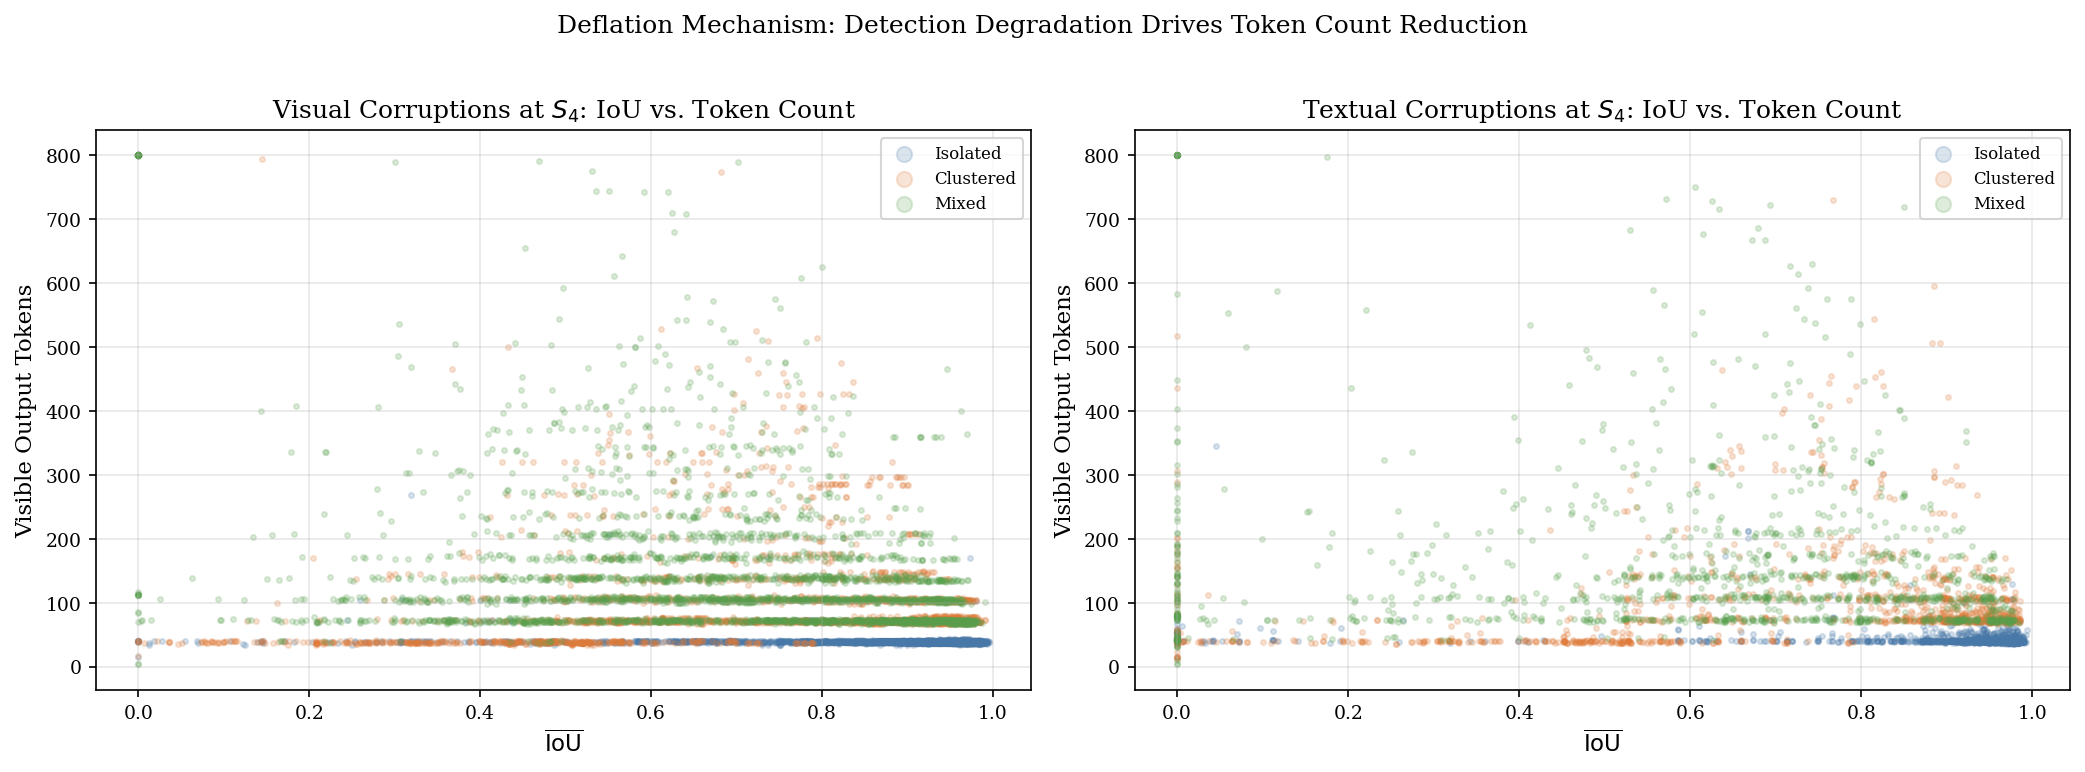

Visual S_4:  p(IoU, tokens) = -0.364
Textual S_4: p(IoU, tokens) = -0.321


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for st in SCENE_ORDER:
    sub = df_img[(df_img.scene_type == st) & (df_img.severity == 4)]
    ax.scatter(sub['IoU'], sub['token_count'], s=6, alpha=0.2,
               color=SCENE_COLORS[st], label=st)
ax.set_xlabel('$\\overline{\\mathrm{IoU}}$')
ax.set_ylabel('Visible Output Tokens')
ax.set_title('Visual Corruptions at $S_4$: IoU vs. Token Count')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)

ax = axes[1]
for st in SCENE_ORDER:
    sub = df_txt[(df_txt.scene_type == st) & (df_txt.severity == 4)]
    ax.scatter(sub['IoU'], sub['token_count'], s=6, alpha=0.2,
               color=SCENE_COLORS[st], label=st)
ax.set_xlabel('$\\overline{\\mathrm{IoU}}$')
ax.set_ylabel('Visible Output Tokens')
ax.set_title('Textual Corruptions at $S_4$: IoU vs. Token Count')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)

fig.suptitle('Deflation Mechanism: Detection Degradation Drives Token Count Reduction',
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_eff_deflation_mechanism.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_eff_deflation_mechanism.png'), dpi=200)
plt.show()

print(f'Visual S_4:  p(IoU, tokens) = {stats.spearmanr(df_img[df_img.severity==4]["IoU"], df_img[df_img.severity==4]["token_count"])[0]:.3f}')
print(f'Textual S_4: p(IoU, tokens) = {stats.spearmanr(df_txt[df_txt.severity==4]["IoU"], df_txt[df_txt.severity==4]["token_count"])[0]:.3f}')

## Unimodal Visual - Token Count by Corruption and Severity

In [15]:
img_tok_pivot = df_img.pivot_table(
    index='corruption', columns='severity', values='token_count', aggfunc='mean'
).round(1)

print('=== Visual Corruptions: Mean Visible Token Count ===')
display(img_tok_pivot)

print('\n=== delta% (S_4 vs S_0) ===')
for corr in img_tok_pivot.index:
    s0 = img_tok_pivot.loc[corr, 0]
    s4 = img_tok_pivot.loc[corr, 4]
    pct = 100 * (s4 - s0) / s0
    print(f'  {IMG_NICE.get(corr, corr):<20s}  S_0={s0:>6.1f}  S_4={s4:>6.1f}  delta={pct:>+6.1f}%')

=== Visual Corruptions: Mean Visible Token Count ===


severity,0,1,2,3,4
corruption,,,,,
contrast,105.3,105.3,105.1,104.4,103.5
cutout,105.1,105.3,101.9,100.9,101.0
defocus_blur,101.3,91.6,90.0,84.4,79.0
elastic,97.8,100.2,97.6,98.5,96.0
false_color,104.1,104.2,104.5,99.6,94.9
fog_filter,107.3,103.5,102.4,103.3,91.6
gaussian_noise,104.1,102.8,101.1,93.7,94.2
grayscale,104.4,104.5,104.8,105.0,103.5
jpeg_filter,102.0,100.7,102.1,100.1,95.6



=== delta% (S_4 vs S_0) ===
  Contrast              S_0= 105.3  S_4= 103.5  delta=  -1.7%
  Cutout                S_0= 105.1  S_4= 101.0  delta=  -3.9%
  Defocus Blur          S_0= 101.3  S_4=  79.0  delta= -22.0%
  Elastic               S_0=  97.8  S_4=  96.0  delta=  -1.8%
  False Color           S_0= 104.1  S_4=  94.9  delta=  -8.8%
  Fog                   S_0= 107.3  S_4=  91.6  delta= -14.6%
  Gaussian Noise        S_0= 104.1  S_4=  94.2  delta=  -9.5%
  Grayscale             S_0= 104.4  S_4= 103.5  delta=  -0.9%
  JPEG                  S_0= 102.0  S_4=  95.6  delta=  -6.3%
  Motion Blur           S_0= 104.3  S_4=  85.6  delta= -17.9%
  Pixelation            S_0= 103.7  S_4=  86.2  delta= -16.9%
  Snow                  S_0= 105.3  S_4= 103.7  delta=  -1.5%


In [16]:
img_rt_pivot = df_img.pivot_table(
    index='corruption', columns='severity', values='runtime_seconds', aggfunc='mean'
).round(3)

print('=== Visual Corruptions: Mean Runtime (seconds) ===')
display(img_rt_pivot)

=== Visual Corruptions: Mean Runtime (seconds) ===


severity,0,1,2,3,4
corruption,,,,,
contrast,2.152,2.775,2.528,2.785,2.141
cutout,2.072,2.817,2.432,2.472,2.110
defocus_blur,1.952,2.089,2.109,1.786,1.295
elastic,1.908,2.685,2.373,2.418,1.951
false_color,2.089,2.861,2.601,2.644,2.005
fog_filter,2.244,2.699,2.486,2.644,1.769
gaussian_noise,2.150,2.741,2.619,2.196,1.902
grayscale,2.025,2.684,2.551,2.595,2.129
jpeg_filter,2.035,2.553,2.535,2.593,1.984


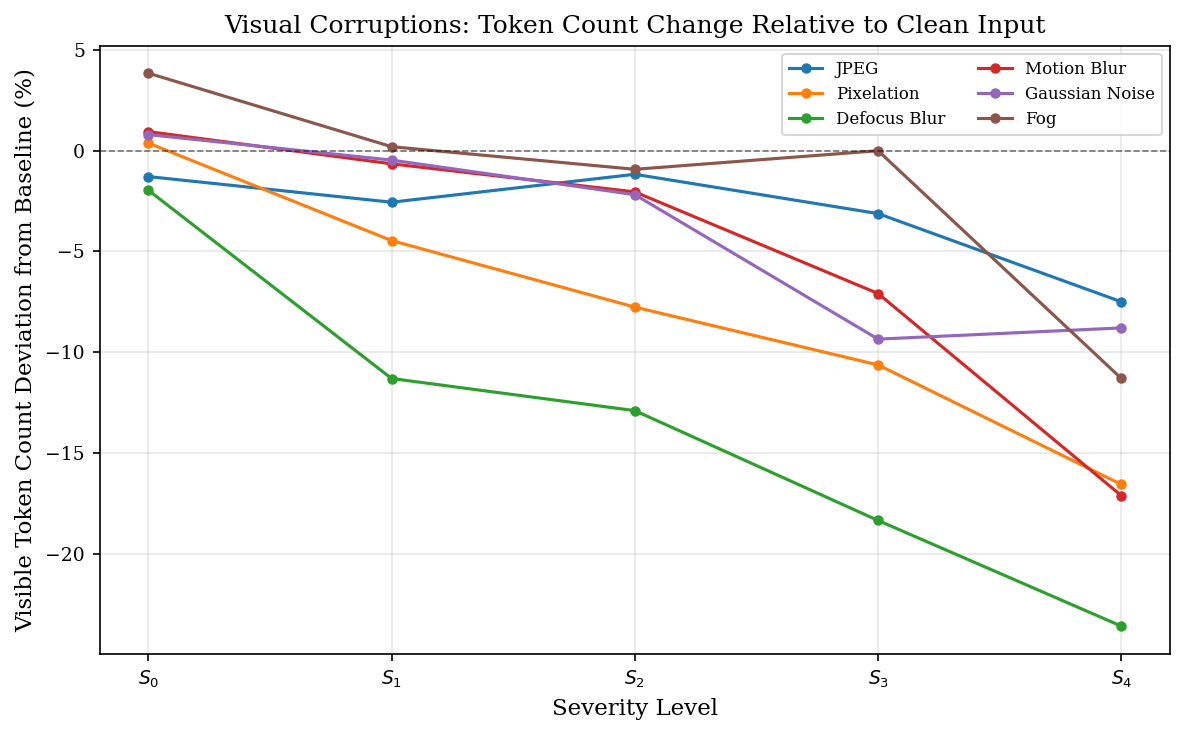

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

for corr in IMAGE_ATTACKS:
    sub = df_img[df_img.corruption == corr].groupby('severity')['token_count'].mean()
    dev = ((sub - bl_tok_mean) / bl_tok_mean * 100)
    ax.plot(dev.index, dev.values, marker='o', markersize=4, linewidth=1.5,
            label=IMG_NICE.get(corr, corr))

ax.axhline(0, color='black', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Severity Level')
ax.set_ylabel('Visible Token Count Deviation from Baseline (%)')
ax.set_title('Visual Corruptions: Token Count Change Relative to Clean Input')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['$S_0$', '$S_1$', '$S_2$', '$S_3$', '$S_4$'])
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_eff_visual_token_deviation.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_eff_visual_token_deviation.png'), dpi=200)
plt.show()

## Unimodal Textual - Token Count by Corruption and Severity

In [18]:
txt_tok_pivot = df_txt.pivot_table(
    index='corruption', columns='severity', values='token_count', aggfunc='mean'
).round(1)
txt_tok_pivot.index = [TXT_NICE.get(c, c) for c in txt_tok_pivot.index]

print('=== Textual Corruptions: Mean Visible Token Count ===')
display(txt_tok_pivot)

print('\n=== delta% (S_4 vs S_0) ===')
for corr in txt_tok_pivot.index:
    s0 = txt_tok_pivot.loc[corr, 0]
    s4 = txt_tok_pivot.loc[corr, 4]
    pct = 100 * (s4 - s0) / s0
    print(f'  {corr:<20s}  S_0={s0:>6.1f}  S_4={s4:>6.1f}  delta={pct:>+6.1f}%')

=== Textual Corruptions: Mean Visible Token Count ===


severity,0,1,2,3,4
Lex. Saliency,102.7,99.1,94.5,92.5,90.1
Char. Noise,106.9,114.8,119.8,127.9,131.5
Fragmentation,103.9,103.3,102.1,101.8,101.2
Homophone,101.8,98.5,95.8,86.5,84.5
Synonym,104.4,102.8,97.4,94.8,96.3



=== delta% (S_4 vs S_0) ===
  Lex. Saliency         S_0= 102.7  S_4=  90.1  delta= -12.3%
  Char. Noise           S_0= 106.9  S_4= 131.5  delta= +23.0%
  Fragmentation         S_0= 103.9  S_4= 101.2  delta=  -2.6%
  Homophone             S_0= 101.8  S_4=  84.5  delta= -17.0%
  Synonym               S_0= 104.4  S_4=  96.3  delta=  -7.8%


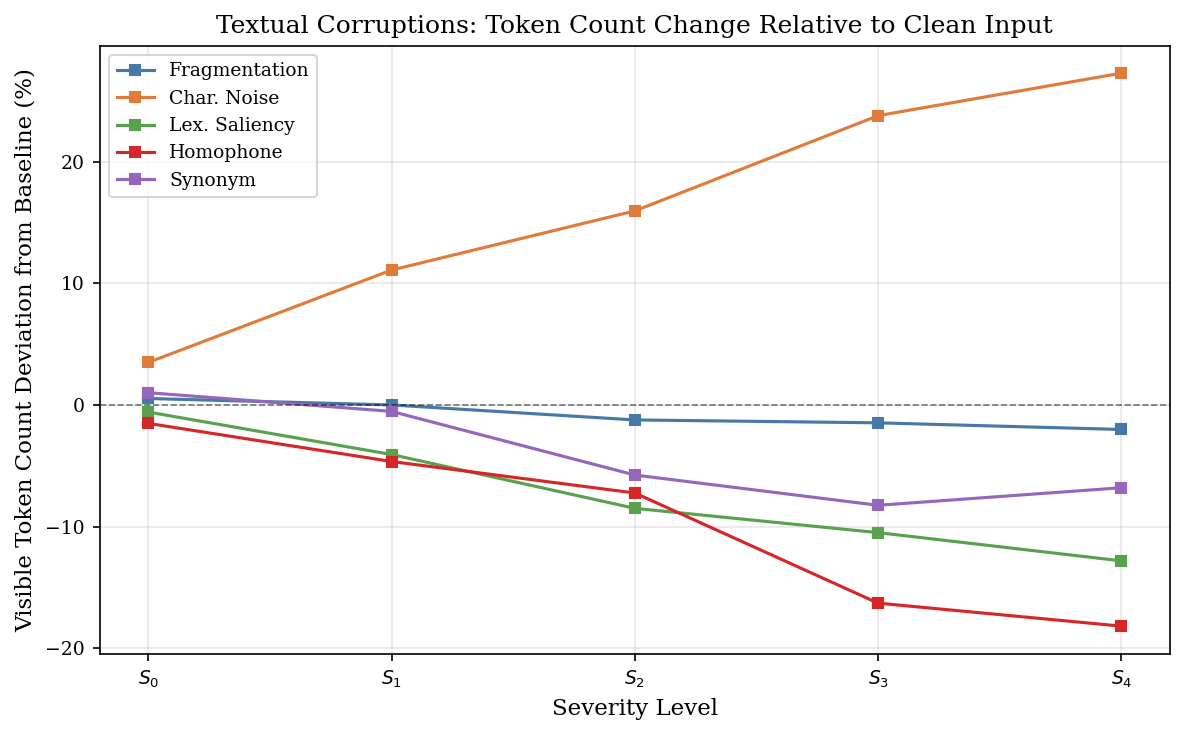

In [19]:
CORR_COLORS_TXT = {
    'fragmentation': '#4878A8', 'character_noise': '#E07B39',
    'ata_saliency': '#59A14F', 'homophone': '#D62728', 'synonym': '#9467BD',
}

fig, ax = plt.subplots(figsize=(8, 5))

for corr in LABEL_LEVEL:
    sub = df_txt[df_txt.corruption == corr].groupby('severity')['token_count'].mean()
    dev = ((sub - bl_tok_mean) / bl_tok_mean * 100)
    ax.plot(dev.index, dev.values, marker='s', markersize=5, linewidth=1.5,
            color=CORR_COLORS_TXT[corr], label=TXT_NICE.get(corr, corr))

ax.axhline(0, color='black', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Severity Level')
ax.set_ylabel('Visible Token Count Deviation from Baseline (%)')
ax.set_title('Textual Corruptions: Token Count Change Relative to Clean Input')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['$S_0$', '$S_1$', '$S_2$', '$S_3$', '$S_4$'])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_eff_textual_token_deviation.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_eff_textual_token_deviation.png'), dpi=200)
plt.show()